# Clasificación de enfermedades en hojas de tomate mediante un MLP

## Evaluación Parcial 1 - Técnicas Avanzadas de Machine Learning

Este notebook implementa un flujo reproducible de aprendizaje supervisado para clasificar imágenes de hojas de tomate utilizando un Perceptrón Multicapa (MLP).

El proyecto incluye:

- Comprensión del problema y definición de una variante propia.
- Análisis exploratorio de datos.
- Preprocesamiento y partición estratificada.
- Implementación de un MLP.
- Entrenamiento y validación.
- Accuracy, Precision, Recall, F1-Score y matriz de confusión.
- Análisis visual de aciertos y errores.
- Comparación opcional con un modelo base.

> La pauta solicita un MLP como modelo base. Por eso no se utiliza una CNN en este trabajo.

## Variante definida

Se seleccionan cinco clases de hojas de tomate:

1. `Tomato_healthy`
2. `Tomato_Early_blight`
3. `Tomato_Late_blight`
4. `Tomato_Leaf_Mold`
5. `Tomato_Bacterial_spot`

Se utilizan como máximo 400 imágenes por clase, para un total máximo de 2.000 imágenes. La semilla 1102 permite reproducir la selección y la división de los datos.

## 1. Instalación y configuración

Ejecuta esta celda una vez. En Google Colab, se recomienda activar una GPU desde **Entorno de ejecución > Cambiar tipo de entorno de ejecución**.

In [3]:
%pip -q install tensorflow seaborn scikit-learn pillow

import os

os.environ["PYTHONHASHSEED"] = "1102"
os.environ["TF_DETERMINISTIC_OPS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [11]:
import random
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from PIL import Image
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

SEED = 1102
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices("GPU"))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Localización del dataset

El notebook busca automáticamente el dataset en la ruta local utilizada para este proyecto, en Google Drive y en carpetas habituales de Google Colab.

Si aparece un error indicando que no se encontró el dataset, modifica `DATA_ROOT_OVERRIDE` con la ruta de la carpeta que contiene las 15 clases.

In [12]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

DATA_ROOT_OVERRIDE = Path(
    "/Users/joseconcha/Downloads/PlantVillage/PlantVillage"
)

ZIP_CANDIDATES = [
    Path("/content/drive/MyDrive/PlantVillage_MLP/PlantVillage.zip"),
    Path("/content/drive/MyDrive/PlantVillage_MLP/PlantVillage/PlantVillage.zip"),
    Path("PlantVillage.zip"),
]

COLAB_EXTRACT_DIR = Path("/content/plantvillage")


def directory_has_images(directory):
    return directory.exists() and any(
        path.is_file() and path.suffix.lower() in IMAGE_EXTS
        for path in directory.rglob("*")
    )


if not directory_has_images(COLAB_EXTRACT_DIR):
    existing_zip = next(
        (path for path in ZIP_CANDIDATES if path.exists()),
        None,
    )

    if existing_zip is not None:
        COLAB_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(existing_zip, "r") as zip_ref:
            zip_ref.extractall(COLAB_EXTRACT_DIR)
        print("Dataset descomprimido desde:", existing_zip)

OUTPUT_DIR = (
    Path("/content/drive/MyDrive/PlantVillage_MLP/outputs")
    if IN_COLAB and Path("/content/drive/MyDrive").exists()
    else Path.cwd() / "plantvillage_outputs"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def list_images(directory):
    return sorted([
        path for path in directory.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS
    ])


def score_dataset_root(directory):
    if not directory.exists() or not directory.is_dir():
        return 0

    score = 0
    child_dirs = [path for path in directory.iterdir() if path.is_dir()]

    for child in child_dirs:
        if any(
            path.is_file() and path.suffix.lower() in IMAGE_EXTS
            for path in child.iterdir()
        ):
            score += 1

    return score


candidate_roots = [
    DATA_ROOT_OVERRIDE,
    Path("/content/plantvillage/PlantVillage"),
    Path("/content/plantvillage"),
    Path("/content/drive/MyDrive/PlantVillage_MLP/PlantVillage/PlantVillage"),
    Path("/content/drive/MyDrive/PlantVillage_MLP/PlantVillage"),
]

candidate_roots += [
    path for base in [Path("/content"), Path("/content/drive/MyDrive")]
    if base.exists()
    for path in base.glob("**/PlantVillage")
    if path.is_dir()
]

candidate_roots = list(dict.fromkeys(candidate_roots))
scored_roots = [
    (score_dataset_root(path), len(path.parts), path)
    for path in candidate_roots
]

valid_roots = [item for item in scored_roots if item[0] >= 5]

if not valid_roots:
    raise FileNotFoundError(
        "No se encontró una carpeta con las clases del dataset. "
        "Modifica DATA_ROOT_OVERRIDE con la ruta correcta."
    )

# Prioritize by score, then by *shorter* path length to avoid __MACOSX directories
DATA_ROOT = max(valid_roots, key=lambda item: (item[0], -item[1]))[2]

print("Dataset seleccionado:", DATA_ROOT)
print("Carpetas de clases:", score_dataset_root(DATA_ROOT))
print("Carpeta de resultados:", OUTPUT_DIR)

Dataset seleccionado: /content/plantvillage/PlantVillage
Carpetas de clases: 15
Carpeta de resultados: /content/drive/MyDrive/PlantVillage_MLP/outputs


## 3. Comprensión del conjunto de datos

La carpeta entregada contiene un subconjunto de PlantVillage. Se reportan las cantidades reales encontradas en la carpeta, no las cifras generales del dataset original.

In [13]:
all_counts = pd.Series({
    directory.name: len(list_images(directory))
    for directory in DATA_ROOT.iterdir()
    if directory.is_dir()
}).sort_values(ascending=False)

display(all_counts.to_frame("cantidad_imagenes"))
print("Número de clases:", len(all_counts))
print("Total de imágenes:", int(all_counts.sum()))

,cantidad_imagenes
Tomato__Tomato_YellowLeaf__Curl_Virus,3208
Tomato_Bacterial_spot,2127
Tomato_Late_blight,1909
Tomato_Septoria_leaf_spot,1771
Tomato_Spider_mites_Two_spotted_spider_mite,1676
Tomato_healthy,1591
Pepper__bell___healthy,1478
Tomato__Target_Spot,1404
Potato___Early_blight,1000
Potato___Late_blight,1000


Número de clases: 15
Total de imágenes: 20638


In [15]:
SELECTED_CLASSES = [
    "Tomato_healthy",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Bacterial_spot",
]

MAX_IMAGES_PER_CLASS = 400

missing_classes = [
    class_name
    for class_name in SELECTED_CLASSES
    if not (DATA_ROOT / class_name).exists()
]

assert not missing_classes, f"Faltan clases: {missing_classes}"

records = []

for class_name in SELECTED_CLASSES:
    for image_path in list_images(DATA_ROOT / class_name):
        records.append({
            "path": str(image_path),
            "label": class_name,
        })

full_df = pd.DataFrame(records)
selected_parts = []

for class_name in SELECTED_CLASSES:
    class_df = full_df[full_df["label"] == class_name]
    sample_size = min(MAX_IMAGES_PER_CLASS, len(class_df))

    selected_parts.append(
        class_df.sample(n=sample_size, random_state=SEED)
    )

df = pd.concat(selected_parts, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

LABEL_TO_ID = {
    label: index
    for index, label in enumerate(SELECTED_CLASSES)
}

df["label_id"] = df["label"].map(LABEL_TO_ID).astype("int32")

print("Imágenes seleccionadas:", len(df))
display(df["label"].value_counts().to_frame("cantidad"))

Imágenes seleccionadas: 2000


,cantidad
label,
Tomato_Early_blight,400
Tomato_healthy,400
Tomato_Late_blight,400
Tomato_Leaf_Mold,400
Tomato_Bacterial_spot,400


### Control de calidad de imágenes

El siguiente control verifica dimensiones, modo de color y archivos dañados en la variante utilizada.

In [16]:
quality_records = []
bad_files = []

for path_string in df["path"]:
    path = Path(path_string)

    try:
        with Image.open(path) as image:
            image.verify()

        with Image.open(path) as image:
            quality_records.append({
                "path": str(path),
                "size": image.size,
                "mode": image.mode,
            })
    except Exception as error:
        bad_files.append({"path": str(path), "error": str(error)})

quality_df = pd.DataFrame(quality_records)

print("Archivos dañados:", len(bad_files))
print("Dimensiones encontradas:")
display(quality_df["size"].value_counts().to_frame("cantidad"))
print("Modos de color encontrados:")
display(quality_df["mode"].value_counts().to_frame("cantidad"))

Archivos dañados: 0
Dimensiones encontradas:


,cantidad
size,
"(256, 256)",2000


Modos de color encontrados:


,cantidad
mode,
RGB,2000


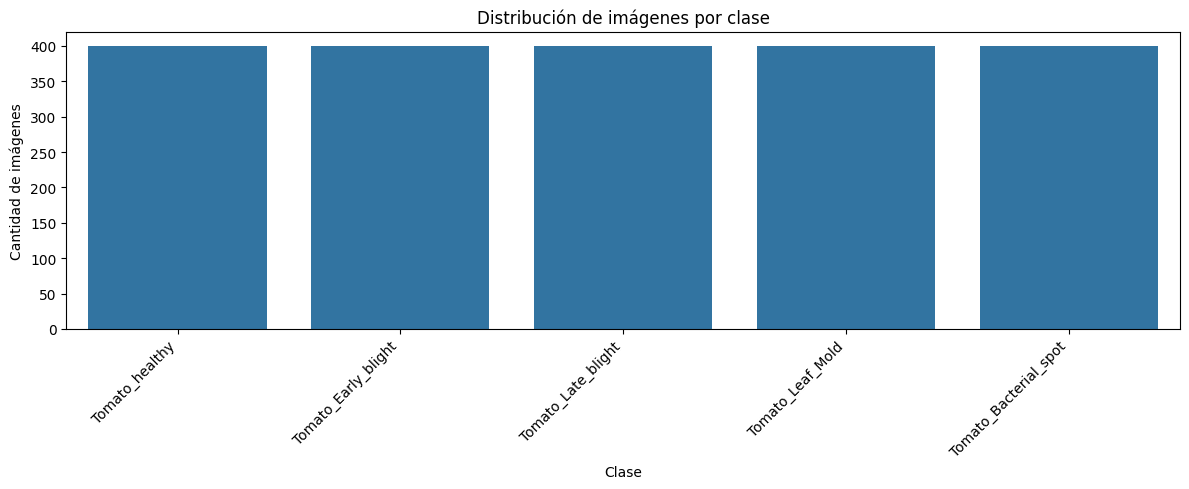

In [17]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x="label", order=SELECTED_CLASSES)
plt.title("Distribución de imágenes por clase")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "distribucion_clases.png", dpi=150, bbox_inches="tight")
plt.show()

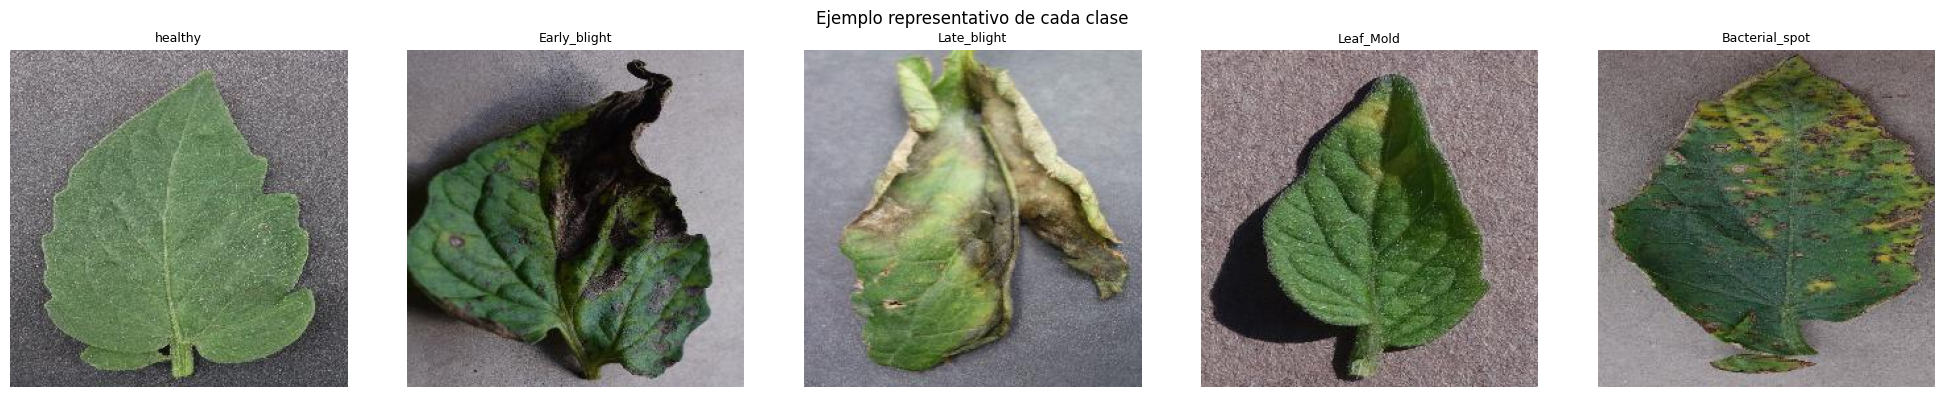

In [18]:
fig, axes = plt.subplots(1, len(SELECTED_CLASSES), figsize=(20, 4))

for ax, class_name in zip(axes, SELECTED_CLASSES):
    sample = (
        df[df["label"] == class_name]
        .sample(1, random_state=SEED)
        .iloc[0]
    )

    image = Image.open(sample["path"]).convert("RGB")
    ax.imshow(image)
    ax.set_title(class_name.replace("Tomato_", ""), fontsize=9)
    ax.axis("off")

plt.suptitle("Ejemplo representativo de cada clase")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "ejemplos_clases.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Partición de datos

Se utiliza una división estratificada de 70% para entrenamiento, 15% para validación y 15% para prueba. La estratificación mantiene la proporción de clases en cada subconjunto.

In [19]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

for split_df in [train_df, val_df, test_df]:
    split_df["label_id"] = (
        split_df["label"].map(LABEL_TO_ID).astype("int32")
    )

print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Prueba:", len(test_df))

display(pd.DataFrame({
    "train": train_df["label"].value_counts(),
    "validation": val_df["label"].value_counts(),
    "test": test_df["label"].value_counts(),
}).fillna(0).astype(int))

Entrenamiento: 1400
Validación: 300
Prueba: 300


,train,validation,test
label,,,
Tomato_Bacterial_spot,280,60,60
Tomato_Early_blight,280,60,60
Tomato_Late_blight,280,60,60
Tomato_Leaf_Mold,280,60,60
Tomato_healthy,280,60,60


## 5. Preprocesamiento y creación de `tf.data.Dataset`

Las imágenes originales se redimensionan a 64 × 64 píxeles, se convierten a RGB y se normalizan al intervalo [0, 1].

In [20]:
IMG_SIZE = (64, 64)
BATCH_SIZE = 32
NUM_CLASSES = len(SELECTED_CLASSES)
AUTOTUNE = tf.data.AUTOTUNE


def load_image(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.image.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.image.convert_image_dtype(image, tf.float32)

    return image, label


def make_dataset(dataframe, shuffle=False):
    paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label_id"].to_numpy(dtype=np.int32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    return (
        dataset
        .map(load_image, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )


train_ds = make_dataset(train_df, shuffle=True)
val_ds = make_dataset(val_df, shuffle=False)
test_ds = make_dataset(test_df, shuffle=False)

sample_images, sample_labels = next(iter(train_ds))
print("Forma de las imágenes:", sample_images.shape)
print("Forma de las etiquetas:", sample_labels.shape)
print("Rango de píxeles:", float(tf.reduce_min(sample_images)), "a", float(tf.reduce_max(sample_images)))

Forma de las imágenes: (32, 64, 64, 3)
Forma de las etiquetas: (32,)
Rango de píxeles: 0.0 a 250.0


## 6. Diseño del Perceptrón Multicapa

La imagen se aplana mediante `Flatten`. La arquitectura principal utiliza dos capas ocultas de 256 y 128 neuronas con activación ReLU, Dropout como regularización y una salida Softmax de cinco clases.

In [21]:
def build_mlp(
    hidden_units=(256, 128),
    dropout_rate=0.35,
    use_augmentation=True,
):
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = inputs

    if use_augmentation:
        x = tf.keras.layers.RandomFlip("horizontal")(x)
        x = tf.keras.layers.RandomRotation(0.05)(x)

    x = tf.keras.layers.Flatten()(x)

    for units in hidden_units:
        x = tf.keras.layers.Dense(units, activation="relu")(x)

        if dropout_rate > 0:
            x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax",
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="MLP_PlantVillage",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


model = build_mlp()
model.summary()

Model: "MLP_PlantVillage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 64, 64, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,179,525 (12.13 MB)

 Trainable params: 3,179,525 (12.13 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Entrenamiento y validación

Se utilizan Early Stopping y reducción automática de la tasa de aprendizaje. Esto ayuda a controlar el sobreajuste y conservar los mejores pesos según la pérdida de validación.

In [22]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.1936 - loss: 587.1483 - val_accuracy: 0.2133 - val_loss: 1.5829 - learning_rate: 0.0010
Epoch 2/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2093 - loss: 1.6993 - val_accuracy: 0.2167 - val_loss: 1.5823 - learning_rate: 0.0010
Epoch 3/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2057 - loss: 3.1851 - val_accuracy: 0.2167 - val_loss: 1.5823 - learning_rate: 0.0010
Epoch 4/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2157 - loss: 1.6179 - val_accuracy: 0.2167 - val_loss: 1.5822 - learning_rate: 0.0010
Epoch 5/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2086 - loss: 1.6355 - val_accuracy: 0.2167 - val_loss: 1.5822 - learning_rate: 0.0010
Epoch 6/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2114 - loss: 1.5975 - val_accuracy: 0.2167 - val_loss: 1.5821 - learning_rate: 0.0010
Epoch 7/25
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2093 - loss: 1.6588 - val_a

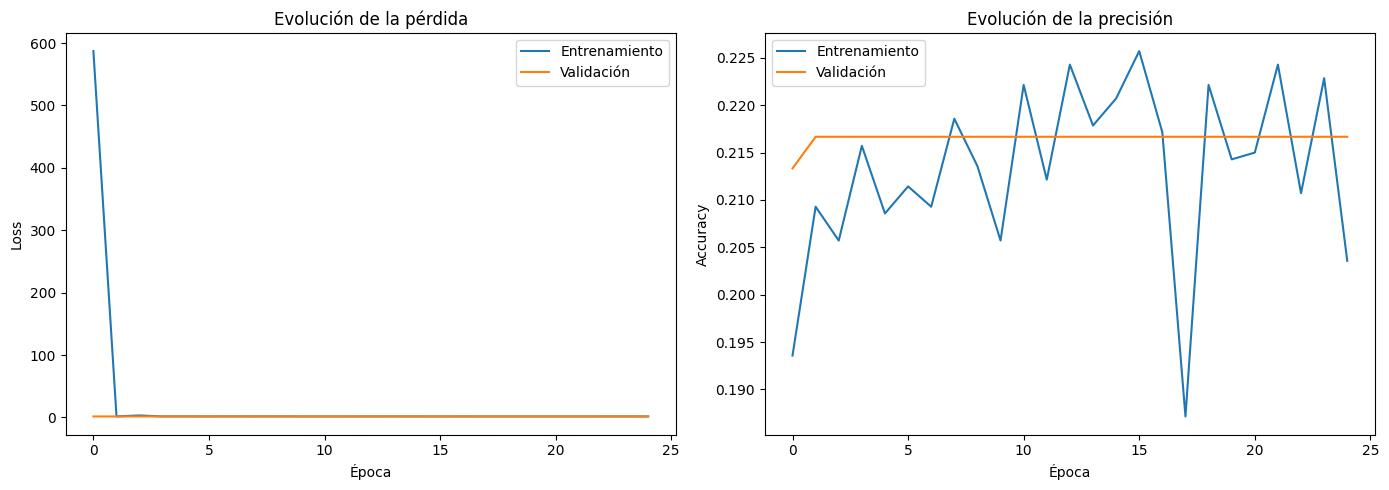

In [23]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["loss"], label="Entrenamiento")
axes[0].plot(history_df["val_loss"], label="Validación")
axes[0].set_title("Evolución de la pérdida")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["accuracy"], label="Entrenamiento")
axes[1].plot(history_df["val_accuracy"], label="Validación")
axes[1].set_title("Evolución de la precisión")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "curvas_entrenamiento.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Evaluación del desempeño

La evaluación se realiza sobre el conjunto de prueba, que no participa en el entrenamiento ni en la selección de los pesos.

In [24]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

y_true = np.concatenate([
    labels.numpy()
    for _, labels in test_ds
])

y_prob = model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

metrics_df = pd.DataFrame({
    "métrica": [
        "Accuracy",
        "Precision macro",
        "Recall macro",
        "F1-Score macro",
    ],
    "valor": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average="macro", zero_division=0),
        recall_score(y_true, y_pred, average="macro", zero_division=0),
        f1_score(y_true, y_pred, average="macro", zero_division=0),
    ],
})

display(metrics_df.round(4))
metrics_df.to_csv(OUTPUT_DIR / "metricas_finales.csv", index=False)

,métrica,valor
0,Accuracy,0.2100
1,Precision macro,0.2404
2,Recall macro,0.2100
3,F1-Score macro,0.0863


In [25]:
report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=SELECTED_CLASSES,
        output_dict=True,
        zero_division=0,
    )
).T

display(report_df.round(4))

,precision,recall,f1-score,support
Tomato_healthy,0.0000,0.00,0.0000,60.00
Tomato_Early_blight,0.2020,1.00,0.3361,60.00
Tomato_Late_blight,1.0000,0.05,0.0952,60.00
Tomato_Leaf_Mold,0.0000,0.00,0.0000,60.00
Tomato_Bacterial_spot,0.0000,0.00,0.0000,60.00
accuracy,0.2100,0.21,0.2100,0.21
macro avg,0.2404,0.21,0.0863,300.00
weighted avg,0.2404,0.21,0.0863,300.00


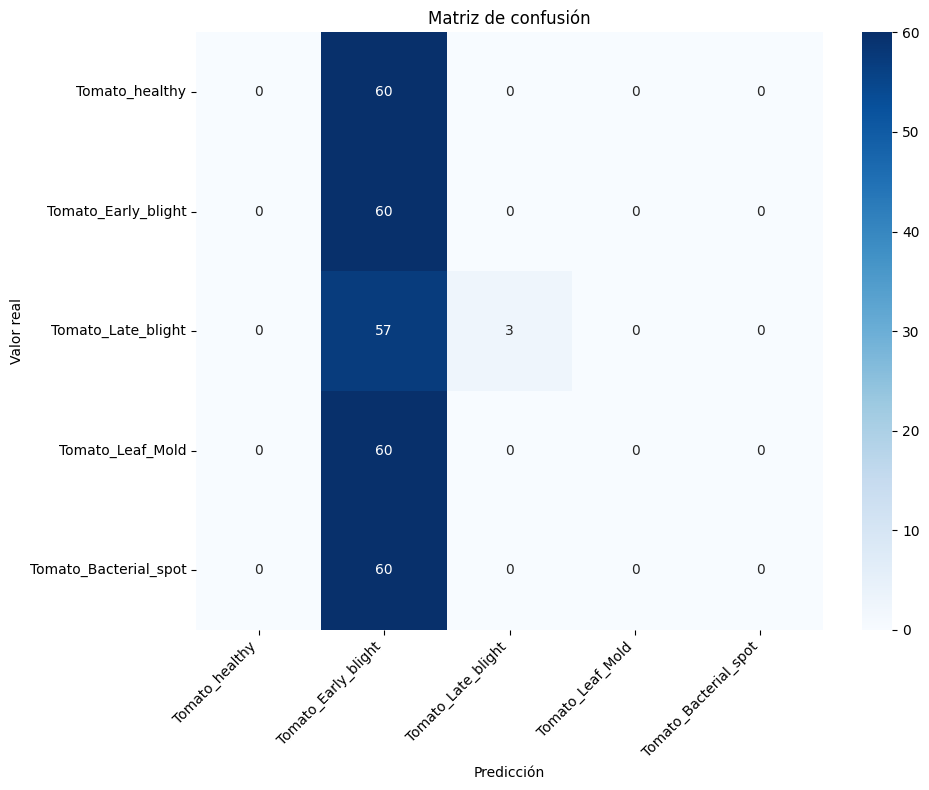

In [26]:
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=SELECTED_CLASSES,
    yticklabels=SELECTED_CLASSES,
)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "matriz_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Análisis de aciertos y errores

Se observan ejemplos correctamente clasificados y ejemplos incorrectos. La confianza corresponde a la probabilidad Softmax de la clase predicha.

In [27]:
results_df = test_df.reset_index(drop=True).copy()
results_df["true_class"] = [SELECTED_CLASSES[index] for index in y_true]
results_df["predicted_class"] = [SELECTED_CLASSES[index] for index in y_pred]
results_df["confidence"] = y_prob.max(axis=1)

wrong_df = results_df[
    results_df["true_class"] != results_df["predicted_class"]
].sort_values("confidence", ascending=False)

correct_df = results_df[
    results_df["true_class"] == results_df["predicted_class"]
].sort_values("confidence", ascending=False)

print("Ejemplos incorrectos:", len(wrong_df))
print("Ejemplos correctos:", len(correct_df))

Ejemplos incorrectos: 237
Ejemplos correctos: 63


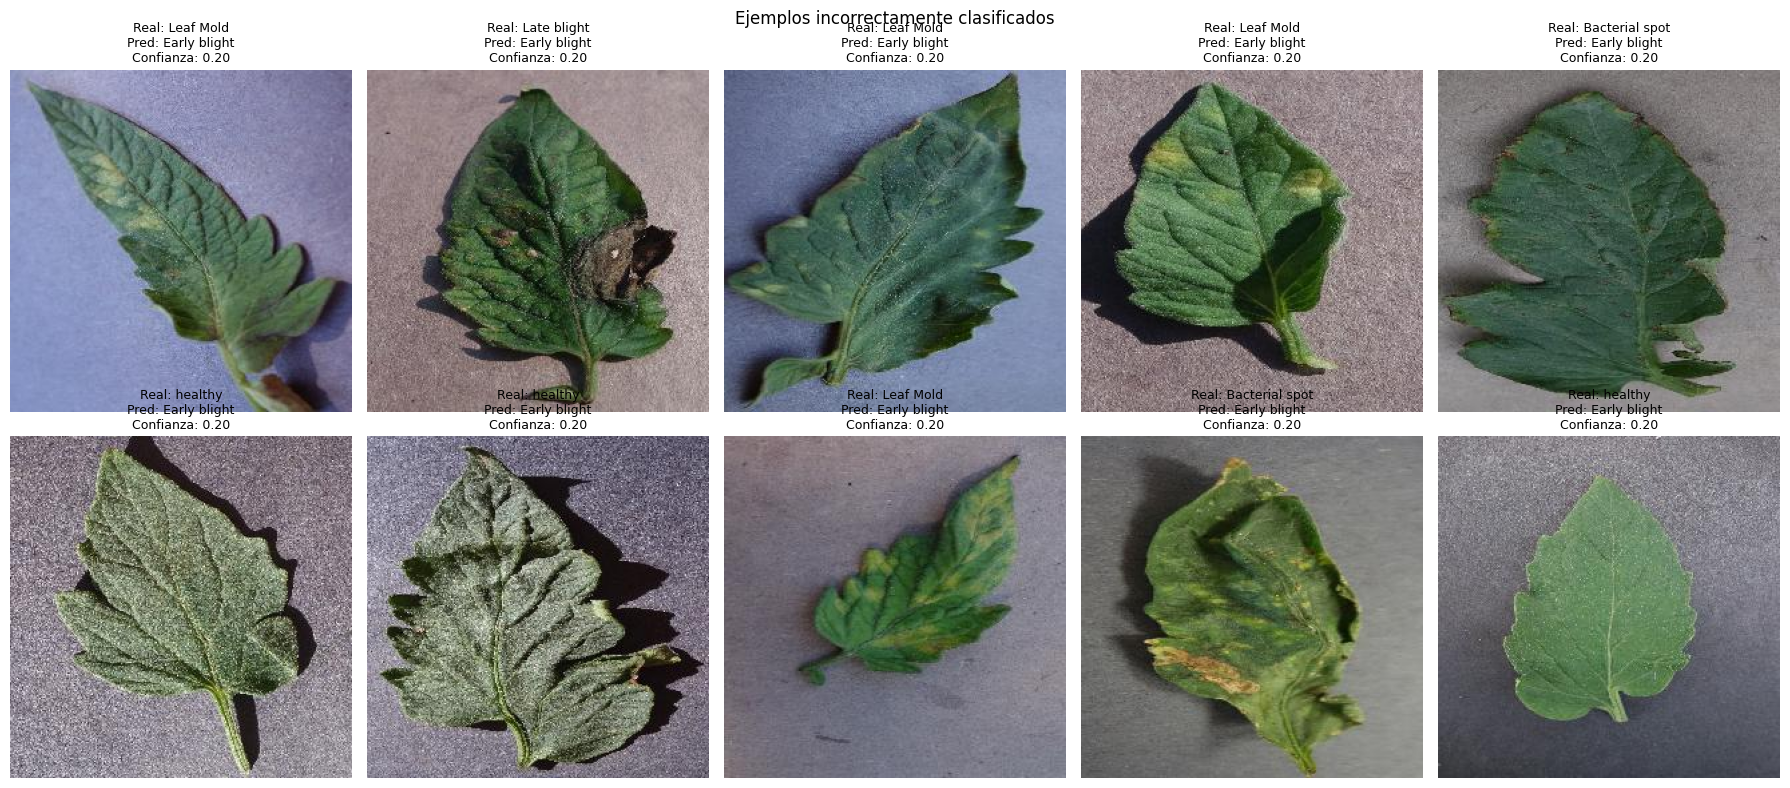

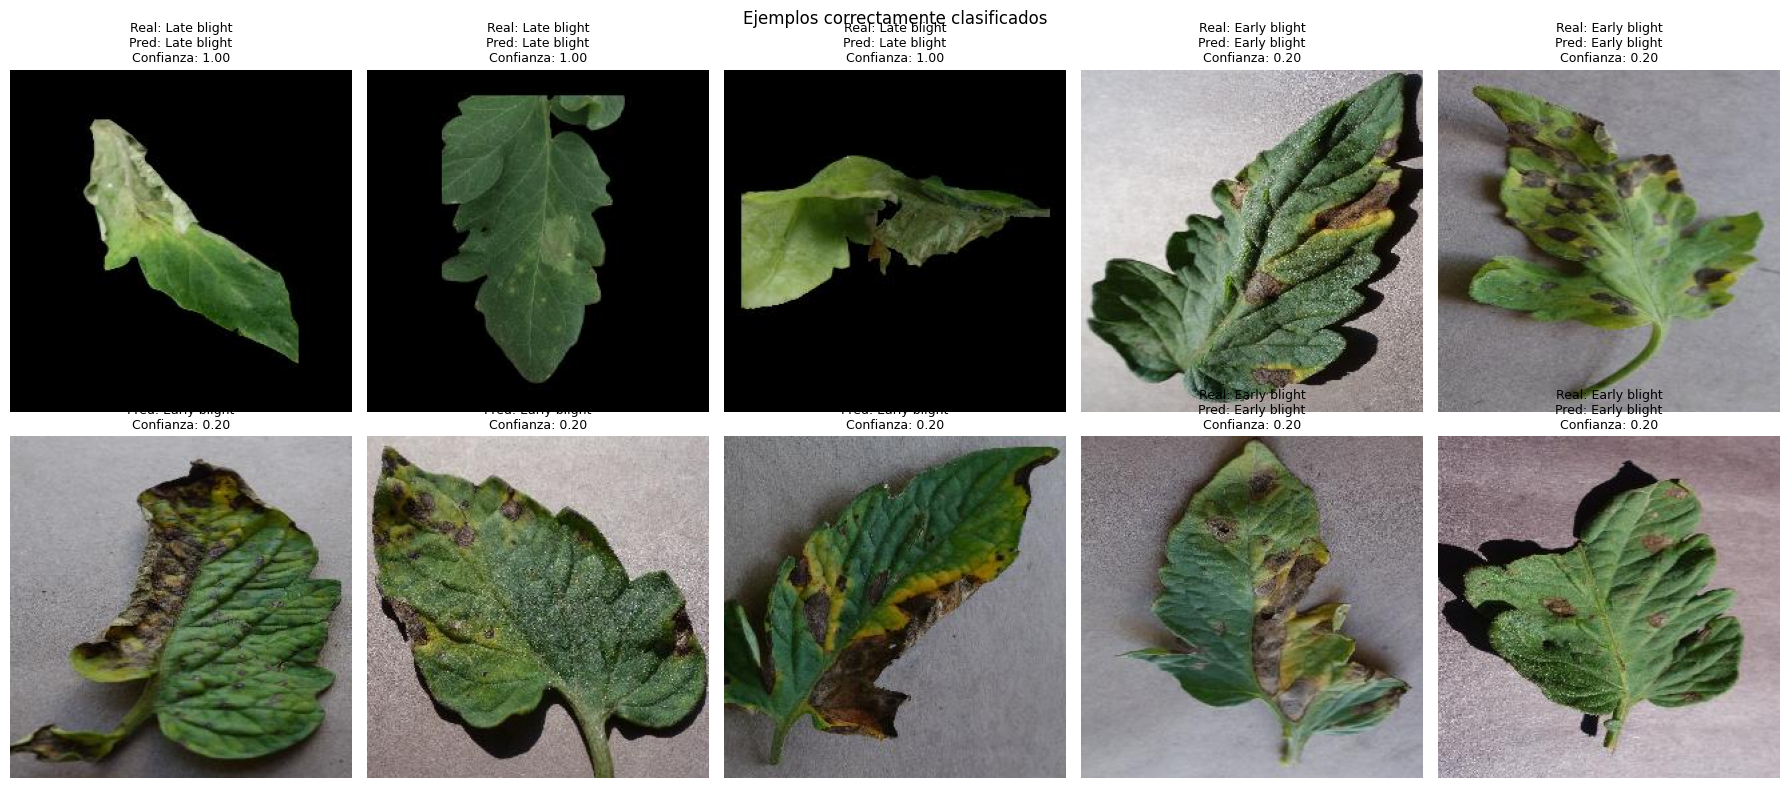

In [28]:
def short_name(name):
    return (
        name
        .replace("Tomato_", "")
        .replace("__", " ")
        .replace("_", " ")
    )


def plot_examples(dataframe, title, n=10):
    dataframe = dataframe.head(n)
    n = len(dataframe)

    if n == 0:
        print("No hay ejemplos para mostrar.")
        return

    columns = min(5, n)
    rows = int(np.ceil(n / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(18, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, dataframe.iterrows()):
        image = Image.open(row["path"]).convert("RGB")
        ax.imshow(image)
        ax.set_title(
            f"Real: {short_name(row['true_class'])}\n"
            f"Pred: {short_name(row['predicted_class'])}\n"
            f"Confianza: {row['confidence']:.2f}",
            fontsize=9,
        )
        ax.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_examples(wrong_df, "Ejemplos incorrectamente clasificados", n=10)
plot_examples(correct_df, "Ejemplos correctamente clasificados", n=10)

In [29]:
cm_without_diagonal = cm.copy()
np.fill_diagonal(cm_without_diagonal, 0)

i, j = np.unravel_index(
    cm_without_diagonal.argmax(),
    cm_without_diagonal.shape,
)

print(
    "Confusión más frecuente:",
    SELECTED_CLASSES[i],
    "predicha como",
    SELECTED_CLASSES[j],
    "con",
    int(cm_without_diagonal[i, j]),
    "casos.",
)

Confusión más frecuente: Tomato_healthy predicha como Tomato_Early_blight con 60 casos.


## 10. Comparación con un MLP base

Esta comparación permite justificar si la arquitectura final mejora respecto de una configuración más sencilla.

In [30]:
RUN_BASELINE_COMPARISON = True

if RUN_BASELINE_COMPARISON:
    baseline = build_mlp(
        hidden_units=(128,),
        dropout_rate=0.0,
        use_augmentation=False,
    )

    baseline.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=3,
                restore_best_weights=True,
            )
        ],
        verbose=1,
    )

    baseline_prob = baseline.predict(test_ds, verbose=0)
    baseline_pred = np.argmax(baseline_prob, axis=1)

    comparison_df = pd.DataFrame({
        "modelo": ["MLP base", "MLP final"],
        "accuracy": [
            accuracy_score(y_true, baseline_pred),
            accuracy_score(y_true, y_pred),
        ],
        "f1_macro": [
            f1_score(y_true, baseline_pred, average="macro", zero_division=0),
            f1_score(y_true, y_pred, average="macro", zero_division=0),
        ],
    })

    display(comparison_df.round(4))

Epoch 1/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2329 - loss: 807.1263 - val_accuracy: 0.2000 - val_loss: 75.3019
Epoch 2/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2121 - loss: 3.7369 - val_accuracy: 0.2067 - val_loss: 1.6564
Epoch 3/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.2107 - loss: 1.5977 - val_accuracy: 0.2100 - val_loss: 1.5963
Epoch 4/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2121 - loss: 1.5916 - val_accuracy: 0.2100 - val_loss: 1.5962
Epoch 5/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.2121 - loss: 1.5916 - val_accuracy: 0.2133 - val_loss: 1.5951
Epoch 6/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2121 - loss: 1.5915 - val_accuracy: 0.2133 - val_loss: 1.5941
Epoch 7/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.2121 - loss: 1.5914 - val_accuracy: 0.2133 - val_loss: 1.5934
Epoch 8/15
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.2136 - loss: 1.5905 - val_accuracy: 0.2133 

,modelo,accuracy,f1_macro
0,MLP base,0.2067,0.0801
1,MLP final,0.2100,0.0863


## 11. Guardar resultados

Los archivos se guardan en `plantvillage_outputs` cuando se ejecuta localmente, o en `PlantVillage_MLP/outputs` cuando se ejecuta en Google Colab con Google Drive montado.

In [31]:
model.save(str(OUTPUT_DIR / "modelo_mlp_plantvillage.keras"))

manifest_df = pd.concat([
    train_df.assign(split="train"),
    val_df.assign(split="validation"),
    test_df.assign(split="test"),
])

manifest_df.to_csv(
    OUTPUT_DIR / "manifest_particiones.csv",
    index=False,
)

print("Resultados guardados en:", OUTPUT_DIR)
for path in sorted(OUTPUT_DIR.iterdir()):
    print(path.name)

Resultados guardados en: /content/drive/MyDrive/PlantVillage_MLP/outputs
curvas_entrenamiento.png
distribucion_clases.png
ejemplos_clases.png
manifest_particiones.csv
matriz_confusion.png
metricas_finales.csv
modelo_mlp_plantvillage.keras


## 12. Texto para el informe técnico

### Problema de negocio

La identificación de enfermedades en hojas puede apoyar el monitoreo agrícola. Este proyecto aborda una clasificación experimental de imágenes de hojas de tomate en cinco categorías. El modelo no reemplaza la evaluación de un especialista y no debe interpretarse como una herramienta de diagnóstico definitivo.

### Objetivo

Implementar y evaluar un Perceptrón Multicapa capaz de clasificar imágenes de hojas de tomate utilizando un flujo reproducible de aprendizaje supervisado.

### KPIs

- Accuracy: proporción total de predicciones correctas.
- Precision macro: promedio de precisión entre las cinco clases.
- Recall macro: promedio de sensibilidad entre las cinco clases.
- F1-Score macro: métrica principal porque entrega la misma importancia a cada clase.
- Matriz de confusión: permite identificar qué clases presentan mayor confusión.

### Preparación

Las imágenes fueron redimensionadas a 64 × 64 píxeles, convertidas a RGB y normalizadas al intervalo [0, 1]. Se utilizaron 400 imágenes por clase, una semilla 1102 y una división estratificada de 70% entrenamiento, 15% validación y 15% prueba.

### Arquitectura

El MLP utiliza una capa Flatten, capas densas de 256 y 128 neuronas con activación ReLU, Dropout, y una capa de salida Softmax de cinco neuronas. Se utilizó Adam con learning rate 0,001 y sparse categorical crossentropy.

### Limitaciones

El MLP trabaja sobre una versión aplanada de la imagen, por lo que no captura explícitamente la estructura espacial local. También puede ser sensible a iluminación, orientación, fondo y diferencias entre imágenes controladas y fotografías reales de campo. Como mejora futura se propone utilizar una CNN, transfer learning, más imágenes y datos tomados en condiciones reales.

### Conclusión

Completa esta sección después de ejecutar el notebook con los valores de `metrics_df`, la matriz de confusión, las curvas de aprendizaje y los ejemplos de error. No inventes métricas: utiliza los resultados generados por el notebook.

## 13. Preguntas para la defensa

1. **¿Por qué se utilizó un MLP?**  Porque es el modelo solicitado por la pauta y permite establecer una línea base para clasificación de imágenes.
2. **¿Por qué Softmax?**  Porque existen cinco clases mutuamente excluyentes.
3. **¿Por qué F1 macro?**  Porque calcula el rendimiento promedio dando igual importancia a todas las clases.
4. **¿Qué indica un aumento de la brecha entre entrenamiento y validación?**  Posible sobreajuste.
5. **¿Cuál es la principal limitación del MLP en imágenes?**  Al aplanar los píxeles se pierde información espacial.
6. **¿Cómo se podría mejorar?**  Con CNN, transfer learning, más datos diversos y aumento de datos.